In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import os
import yaml

from deepracer.tracks import TrackIO, Track
from deepracer.tracks.track_utils import track_breakdown, track_meta
from deepracer.logs import \
    SimulationLogsIO as slio, \
    NewRewardUtils as nr, \
    AnalysisUtils as au, \
    PlottingUtils as pu, \
    ActionBreakdownUtils as abu, \
    DeepRacerLog, \
    S3FileHandler, FSFileHandler

# Ignore deprecation warnings we have no power over
import warnings
warnings.filterwarnings('ignore')

# list model names in bucket

bucket_contents = os.listdir('\\\\wsl.localhost\\Ubuntu\\home\\spencer\\deepracer-for-cloud\\data\\minio\\bucket')
bucket_contents.sort()
for folder in bucket_contents:
    print(folder)
    

## Load Model Name

In [2]:
PREFIX='Sp2026_physical_model_12'

In [3]:
#Load Data into dataframe
BUCKET='bucket'       # Bucket name is default 'bucket' when training locally
PROFILE='minio'          # The credentials profile in .aws - 'minio' for local training
## if you are using this notebook in windows and looking for the IP address to access WSL use the command 
# $hostname -I
# If running this notebook within WSL you can use 'http://minio:9000'
S3_ENDPOINT_URL='http://172.29.159.154:9000'
# If you want to pull files from your bucket folder type the address aboove into your browser and change "9000" to "9001"
# e.g. (http://172.22.79.106:9001)
# look up the docker container named miinio... and "inspect"  it to find the credentials to log in.

fh = S3FileHandler(bucket=BUCKET, prefix=PREFIX, profile=PROFILE, s3_endpoint_url=S3_ENDPOINT_URL)
log = DeepRacerLog(filehandler=fh)
log.load_training_trace()
bin_reward = fh.get_file(PREFIX + '/reward_function.py')
bin_reward = bin_reward.decode()
training_paramas = fh.get_file(PREFIX + '/training_params.yaml')
df = log.dataframe()


new reward not found, using reward as its values
Multiple workers have been detected, reloading data with grouping by unique_episode
Grouping by 'unique_episode'
Number of episodes =  99
Number of iterations =  9


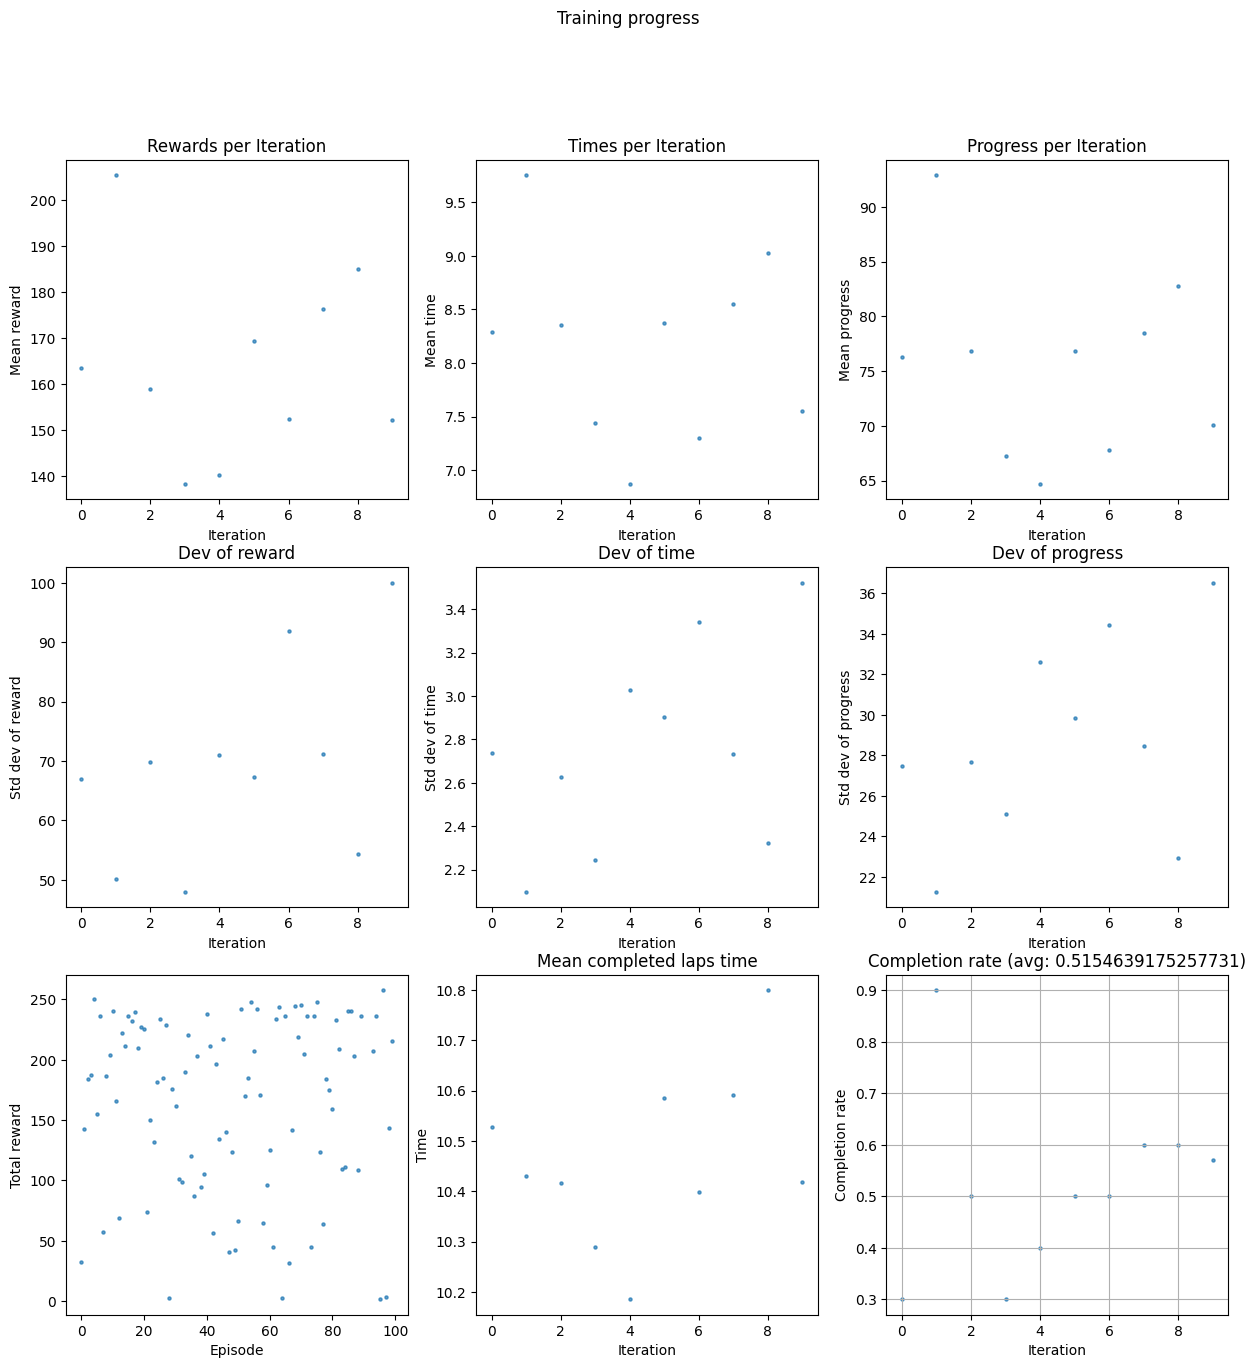

<Figure size 640x480 with 0 Axes>

In [4]:
# Print Core Training Data
simulation_agg = au.simulation_agg(df)
try: 
    if df.nunique(axis=0)['worker'] > 1:
        print("Multiple workers have been detected, reloading data with grouping by unique_episode")
        simulation_agg = au.simulation_agg(df, secondgroup="unique_episode")
except:
    print("Multiple workers not detected, assuming 1 worker")

au.analyze_training_progress(simulation_agg, title='Training progress')
iterations = np.max(df['iteration'])

In [5]:
# Load Track Info
tu = TrackIO('C:\\Users\\spenc\\Documents\\Local_Deepracer_Analysis\\tracks')
yaml_params = yaml.safe_load(training_paramas)
training_track = yaml_params['WORLD_NAME']
direction = yaml_params['REVERSE_DIR']
track: Track = tu.load_track(training_track)
print('----'*25)
print(training_track)
if direction == 'True':
    print('Reverse Direction')
else:
    print('Standard Direction')

#pu.plot_trackpoints(track)

Loaded 112 waypoints
----------------------------------------------------------------------------------------------------
reInvent2019_wide
Reverse Direction


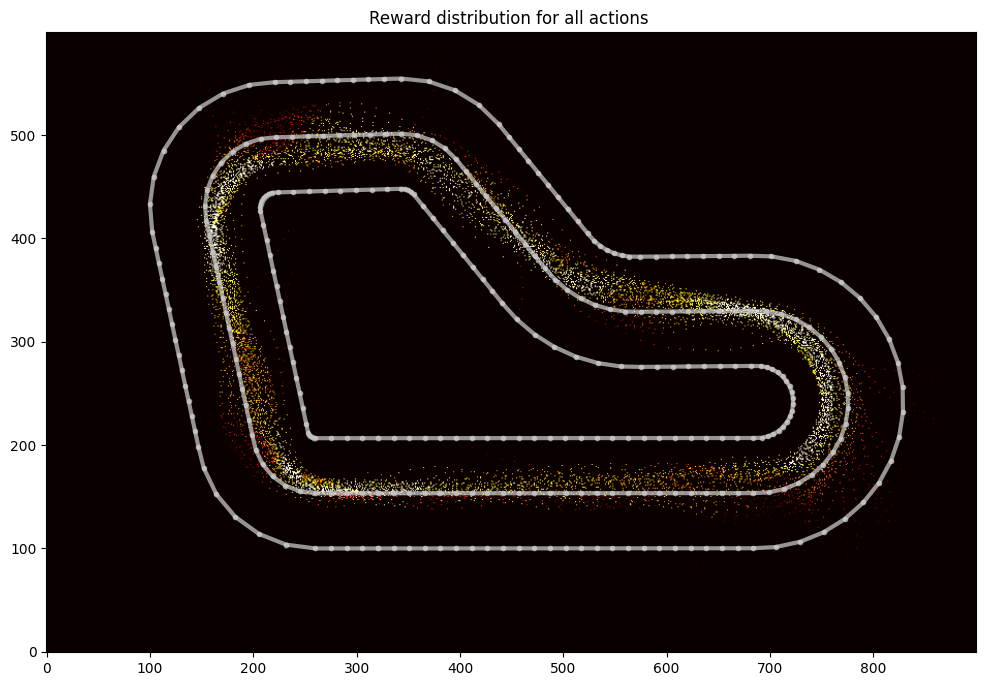

<Figure size 640x480 with 0 Axes>

In [6]:
#plot track reward heatmap
pu.plot_track(df, track)

Plotting iteration 7


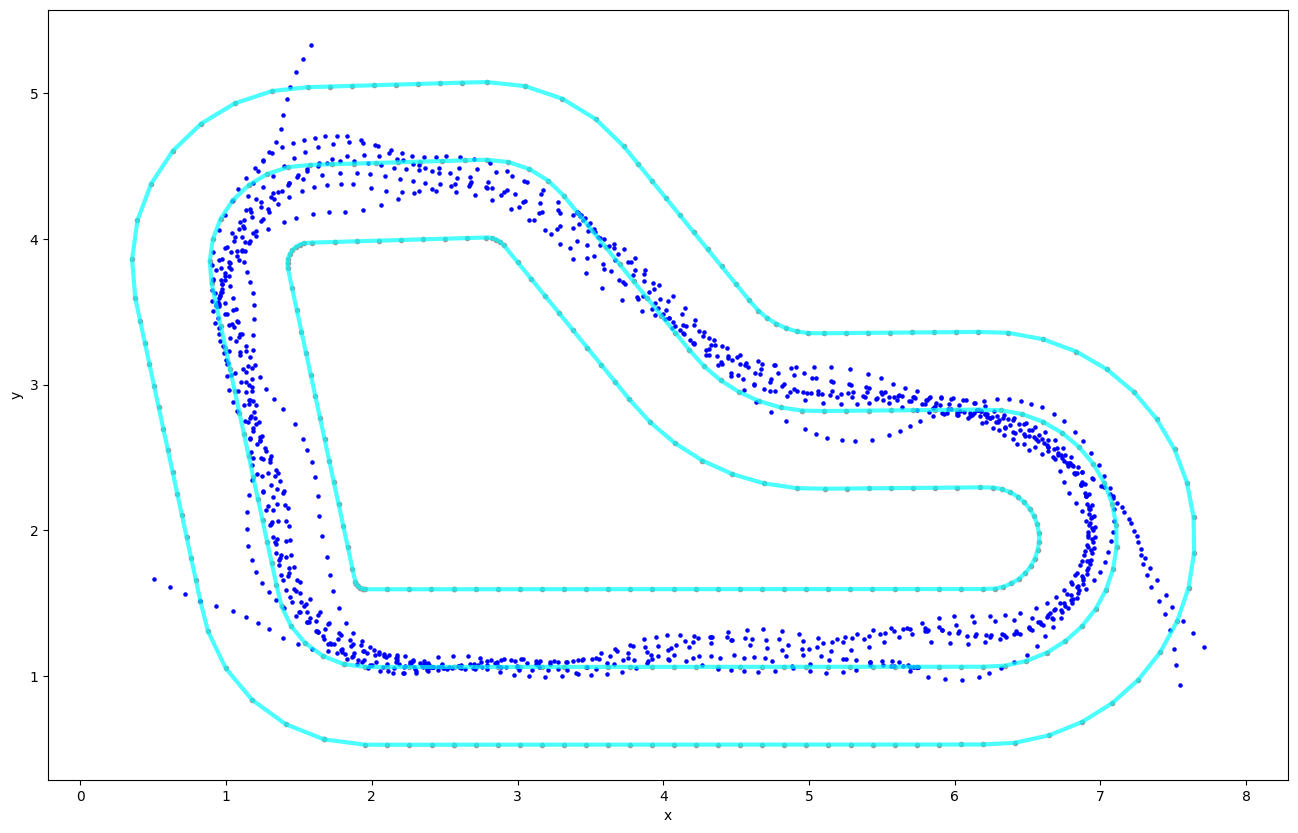

Plotting iteration 8


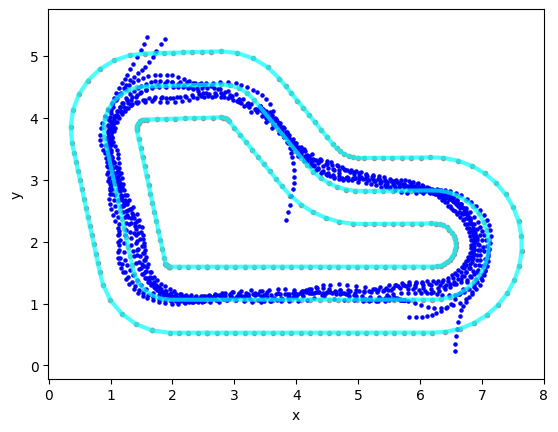

Plotting iteration 9


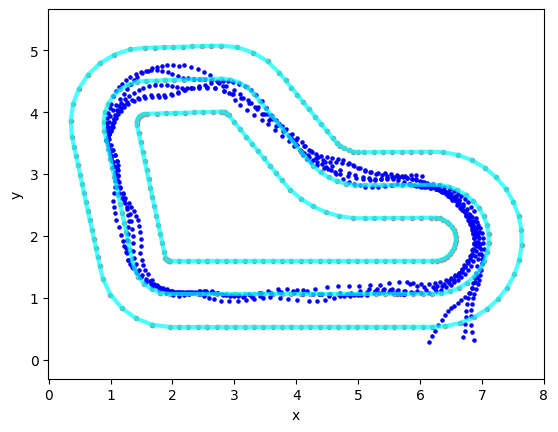

<Figure size 640x480 with 0 Axes>

In [7]:
# Plot the path of the 3 most recent iterations
for i in range(iterations-2, iterations+1):
    print(f"Plotting iteration {i}")
    pu.plot_selected_laps([i], df, track, section_to_plot = 'iteration')

## Model Hyperparameters, Action Space and Reward Function

In [8]:
# print model info

pprint(log.hyperparameters())
print('----'*25)
pprint(log.action_space())
print('----'*25)
print(bin_reward)

{'batch_size': 128,
 'beta_entropy': 0.0001,
 'discount_factor': 0.96,
 'e_greedy_value': 0.05,
 'epsilon_steps': 10000,
 'exploration_type': 'categorical',
 'loss_type': 'huber',
 'lr': 5e-05,
 'num_episodes_between_training': 10,
 'num_epochs': 3,
 'stack_size': 1,
 'term_cond_avg_score': 350.0,
 'term_cond_max_episodes': 50}
----------------------------------------------------------------------------------------------------
{'speed': {'high': 3, 'low': 1}, 'steering_angle': {'high': 30, 'low': -30}}
----------------------------------------------------------------------------------------------------
import math

class Reward:
    def __init__(self, verbose=False):
        self.previous_target = None # index of target waypoint
        self.previous_position = None

    @staticmethod
    def get_vector_length(v):
        return (v[0] ** 2 + v[1] ** 2) ** 0.5

    @staticmethod
    def vector(a, b):
        return b[0] - a[0], b[1] - a[1]
    
    @staticmethod
    def get_direction(wp1